# Virágfelismerés – Adatok betöltése és előkészítése

Ebben a notebookban betöltöm a virágképeket tartalmazó adathalmazt, előkészítem a modelltanításhoz, és megjelenítek néhány mintaképet.

A notebook célja:
- a dataset betöltésének ellenőrzése
- a kategóriák azonosítása
- az adatok előkészítése a modellezéshez
- mintaképek megjelenítése

## CRISP-DM – Adatelőkészítés

A CRISP-DM módszertan harmadik lépése az **adatelőkészítés**.

Ebben a lépésben:
- a képeket betöltjük a megadott mappastruktúrából
- a képeket egységes méretre alakítjuk
- a képeket tanító és validációs halmazra bontjuk
- ellenőrizzük, hogy a kategóriák megfelelően betöltődtek-e

In [1]:
import os
import tarfile
import urllib.request

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Projektgyökér meghatározása helyi Jupyter és Colab futtatáshoz.
cwd = Path.cwd()
possible_roots = [
    cwd,
    cwd.parent,
    Path("/content/adatelemzesi-projekt"),
    Path("/content/drive/MyDrive/adatelemzesi-projekt"),
]

PROJECT_ROOT = None
for candidate in possible_roots:
    if (candidate / "notebooks").exists() and (candidate / "README.md").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    if cwd.name == "notebooks" and (cwd.parent / "README.md").exists():
        PROJECT_ROOT = cwd.parent
    else:
        PROJECT_ROOT = cwd

NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
if NOTEBOOKS_DIR.exists() and Path.cwd() != NOTEBOOKS_DIR:
    os.chdir(NOTEBOOKS_DIR)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATASET_PATH = DATA_RAW_DIR / "flower_photos"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
MODELS_DIR = PROJECT_ROOT / "outputs" / "models"

for directory in [DATA_RAW_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Automatikus adathalmaz-letöltés, ha hiányzik (Colabban nem kell Kaggle token).
DATASET_URL = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
if not DATASET_PATH.exists():
    archive_path = DATA_RAW_DIR / "flower_photos.tgz"
    print(f"Az adathalmaz nem található itt {DATASET_PATH}. letöltés innen: {DATASET_URL}")
    urllib.request.urlretrieve(DATASET_URL, archive_path)
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(DATA_RAW_DIR)
    archive_path.unlink(missing_ok=True)
    print(f"Adathalmaz kicsomagolva ide: {DATASET_PATH}")
else:
    print(f"Adathalmaz megtalálva: {DATASET_PATH}")

print(f"Projekt gyökérmappa: {PROJECT_ROOT}")


## Adathalmaz elérési útja és alap paraméterek

In [2]:
dataset_path = DATASET_PATH

img_height = 180
img_width = 180
batch_size = 32

dataset_path


PosixPath('../data/raw/flower_photos')

## A képek betöltése

A datasetet 80% tanító és 20% validációs halmazra bontjuk.

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [4]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


## Kategóriák azonosítása magyar megnevezésekkel

In [5]:
class_names = train_ds.class_names

hungarian_labels = {
    "daisy": "százszorszép",
    "dandelion": "pitypang",
    "roses": "rózsa",
    "sunflowers": "napraforgó",
    "tulips": "tulipán"
}

print("Kategóriák (angol):", class_names)
print("Kategóriák (magyar):", [hungarian_labels[name] for name in class_names])

class_labels_df = pd.DataFrame({
    "kategoria_angol": class_names,
    "kategoria_magyar": [hungarian_labels[name] for name in class_names]
})
class_labels_path = TABLES_DIR / "01_class_labels.csv"
class_labels_df.to_csv(class_labels_path, index=False)
print(f"Táblázat mentve: {class_labels_path}")


Kategóriák (angol): ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Kategóriák (magyar): ['százszorszép', 'pitypang', 'rózsa', 'napraforgó', 'tulipán']


## Mintaképek megjelenítése

A következő ábra néhány példaképet mutat a tanítóhalmazból.

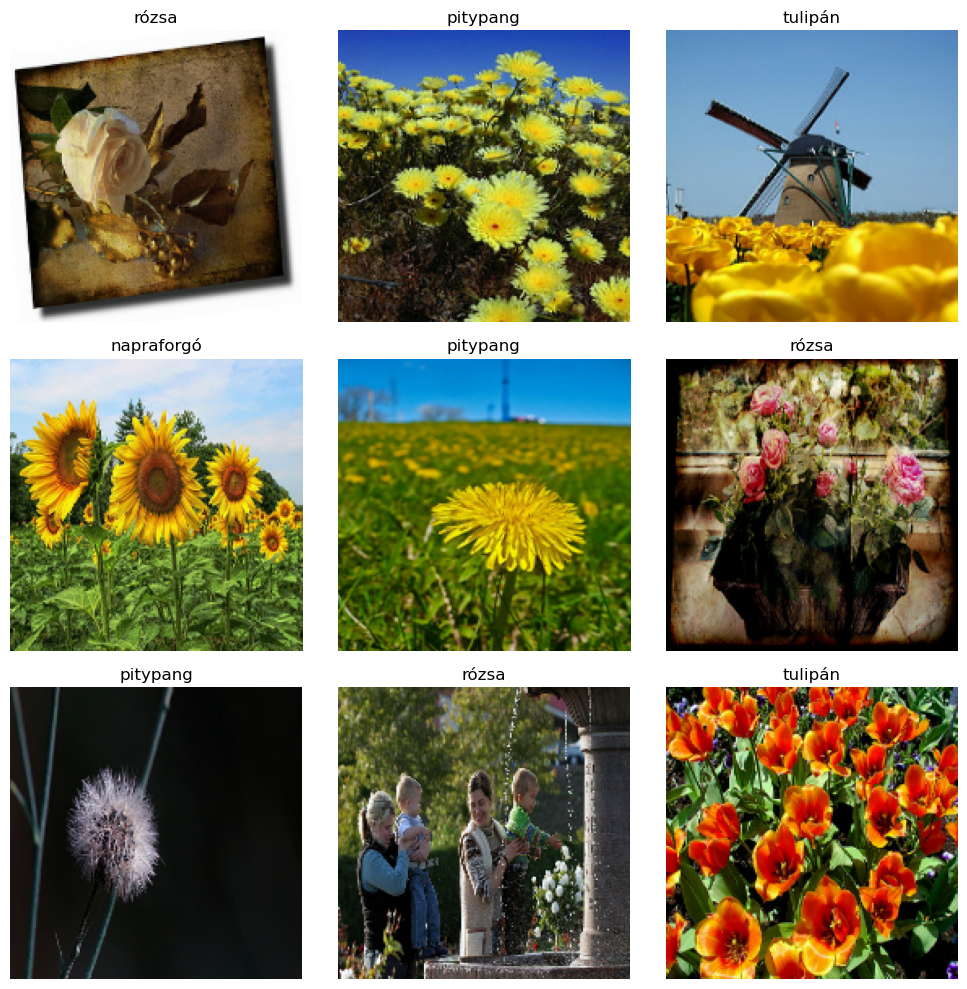

In [6]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(hungarian_labels[class_names[labels[i]]])
        plt.axis("off")

plt.tight_layout()
sample_images_path = FIGURES_DIR / "01_sample_training_images.png"
plt.savefig(sample_images_path, dpi=300, bbox_inches="tight")
print(f"Ábra mentve: {sample_images_path}")
plt.show()


## Adatelőkészítés összefoglalása

Az adatok előkészítése során:
- a képeket sikeresen betöltöttem a könyvtárstruktúrából,
- egységes 180×180 pixeles méretet állítottam be,
- a datasetet tanító és validációs halmazra bontottam,
- ellenőriztem a kategóriák helyes betöltését,
- vizuálisan is megjelenítettem mintaképeket az adatok ellenőrzésére.

Ez a lépés előkészíti a következő fázist, az adatfeltáró elemzést és a modell tanítását.